Using device: cuda
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


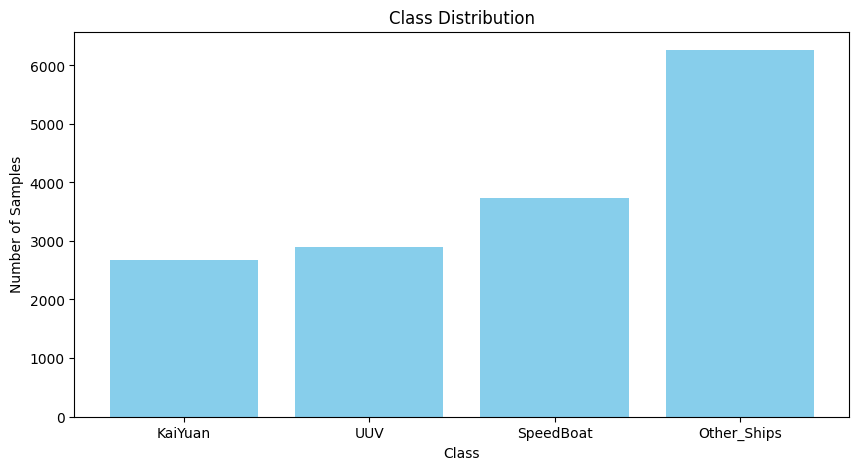

KaiYuan durations stats:
  Total samples: 100
  Min duration: 3.00
  Max duration: 3.00
  Mean duration: 3.00
UUV durations stats:
  Total samples: 100
  Min duration: 3.00
  Max duration: 3.00
  Mean duration: 3.00
SpeedBoat durations stats:
  Total samples: 100
  Min duration: 3.00
  Max duration: 3.00
  Mean duration: 3.00
Other_Ships durations stats:
  Total samples: 100
  Min duration: 3.00
  Max duration: 3.00
  Mean duration: 3.00


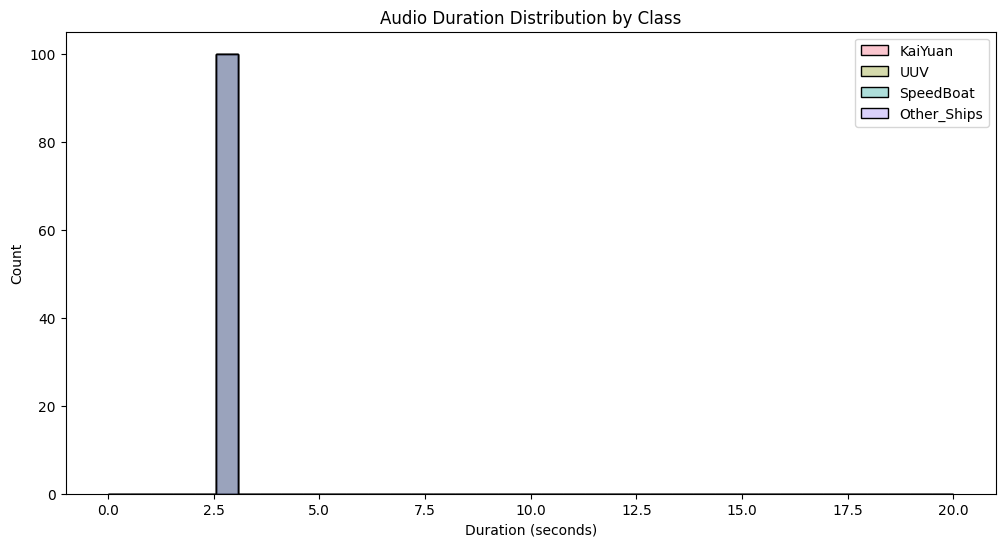

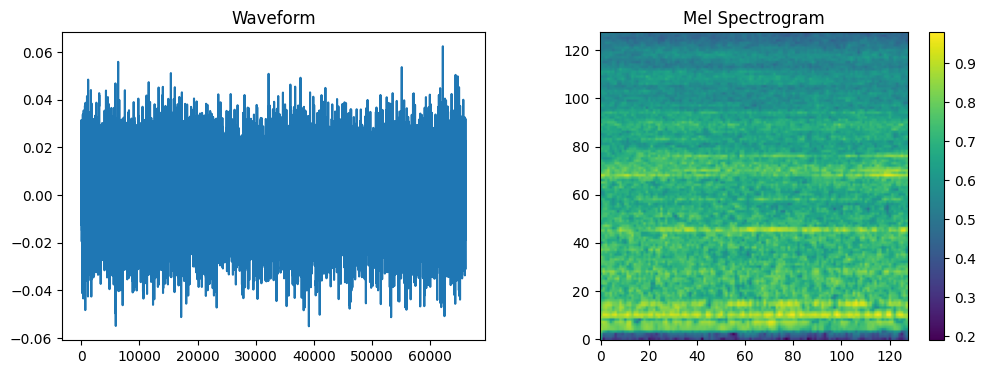

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(
/tmp/ipython-input-10-2954899803.py:319: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=USE_AMP)


Train size: 10899
Validation size: 2335
Test size: 2336
Training CNN...


Epoch 1/20:   0%|          | 0/171 [03:28<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Audio, display
import torch
import torchaudio
from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import transforms
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
from tqdm import tqdm
from torch.cuda.amp import GradScaler, autocast
from itertools import cycle
from diffusers import DDPMScheduler, UNet2DModel
from diffusers.optimization import get_cosine_schedule_with_warmup
from google.colab import drive

# ======================
# 0. Setup and Configuration
# ======================

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check for GPU availability and clear cache
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.empty_cache()
print(f"Using device: {device}")

# Optimized training parameters
BATCH_SIZE = 64 if torch.cuda.is_available() else 16
GRAD_ACCUM_STEPS = 2  # Accumulate gradients before updating
USE_AMP = True  # Mixed precision training
NUM_WORKERS = 4 if torch.cuda.is_available() else 2

# ======================
# 1. Data Loading and Preprocessing
# ======================

# Mount Google Drive and extract dataset
drive.mount('/content/drive')
dataset_zip_path = "/content/drive/MyDrive/QiandaoEar22.zip"
extract_path = "/content/dataset"

if not os.path.exists(extract_path):
    !unzip "{dataset_zip_path}" -d "{extract_path}"

dataset_path = os.path.join(extract_path, "QiandaoEar22")
os.makedirs("/content/models", exist_ok=True)

# Dataset classes
classes = ["KaiYuan", "UUV", "SpeedBoat", "Other_Ships"]

# ======================
# 1.1 Enhanced Dataset Analysis
# ======================

def analyze_dataset(dataset_path):
    # File count analysis
    class_stats = {}
    for class_name in classes:
        class_dir = os.path.join(dataset_path, class_name)
        if os.path.exists(class_dir):
            wav_files = [f for f in os.listdir(class_dir) if f.endswith('.wav')]
            class_stats[class_name] = len(wav_files)
        else:
            print(f"Warning: Missing folder for class {class_name}")

    # Plot class distribution
    plt.figure(figsize=(10, 5))
    plt.bar(class_stats.keys(), class_stats.values(), color='skyblue')
    plt.title("Class Distribution")
    plt.xlabel("Class")
    plt.ylabel("Number of Samples")
    plt.show()

    # Duration analysis
    duration_stats = {cls: [] for cls in classes}
    for class_name in classes:
        class_dir = os.path.join(dataset_path, class_name)
        if not os.path.exists(class_dir):
            continue
        for file in os.listdir(class_dir)[:100]:  # Sample first 100 files
            if file.endswith('.wav'):
                path = os.path.join(class_dir, file)
                try:
                    waveform, sample_rate = torchaudio.load(path)
                    duration = waveform.shape[1] / sample_rate
                    if np.isfinite(duration) and duration > 0:
                        duration_stats[class_name].append(duration)
                except Exception as e:
                    print(f"Error loading {file} in {class_name}: {e}")

    # Debug print durations per class
    for cls in classes:
        durations = np.array(duration_stats[cls])
        print(f"{cls} durations stats:")
        print(f"  Total samples: {len(durations)}")
        if len(durations) > 0:
            print(f"  Min duration: {np.min(durations):.2f}")
            print(f"  Max duration: {np.max(durations):.2f}")
            print(f"  Mean duration: {np.mean(durations):.2f}")
        else:
            print("  No valid durations found.")

    # Plot duration distributions
    plt.figure(figsize=(12, 6))
    max_duration = 20.0
    bins = np.linspace(0, max_duration, 40)
    palette = sns.color_palette("husl", len(classes))
    for i, cls in enumerate(classes):
        durations = np.array(duration_stats[cls])
        durations = durations[np.isfinite(durations)]
        durations = durations[durations <= max_duration]
        if len(durations) > 0:
            sns.histplot(durations, label=cls, kde=True, bins=bins, alpha=0.4, color=palette[i])
        else:
            print(f"No durations to plot for class {cls}")

    plt.title('Audio Duration Distribution by Class')
    plt.xlabel('Duration (seconds)')
    plt.ylabel('Count')
    plt.legend()
    plt.show()

    return class_stats


# Run the analysis
class_stats = analyze_dataset(dataset_path)


# ======================
# 1.2 Audio Processing
# ======================

# Audio parameters
SAMPLE_RATE = 22050
N_FFT = 1024  # Reduced from 2048 for speed
HOP_LENGTH = 256  # Reduced from 512 for speed
N_MELS = 128
IMAGE_SIZE = 128
MAX_DURATION = 5.0  # seconds

class AudioToSpectrogram:
    def __init__(self, sample_rate=SAMPLE_RATE, n_fft=N_FFT, hop_length=HOP_LENGTH,
                 n_mels=N_MELS, image_size=IMAGE_SIZE):
        self.mel_spectrogram = torchaudio.transforms.MelSpectrogram(
            sample_rate=sample_rate,
            n_fft=n_fft,
            hop_length=hop_length,
            n_mels=n_mels
        )
        self.amplitude_to_db = torchaudio.transforms.AmplitudeToDB()
        self.resize = transforms.Resize((image_size, image_size))

    def __call__(self, waveform):
        spectrogram = self.mel_spectrogram(waveform)
        spectrogram = self.amplitude_to_db(spectrogram)
        spectrogram = (spectrogram - spectrogram.min()) / (spectrogram.max() - spectrogram.min())
        return self.resize(spectrogram)

# Test spectrogram conversion
sample_class = next(iter(class_stats.keys()))
sample_file = os.listdir(os.path.join(dataset_path, sample_class))[0]
sample_path = os.path.join(dataset_path, sample_class, sample_file)

waveform, sample_rate = torchaudio.load(sample_path)
if sample_rate != SAMPLE_RATE:
    waveform = torchaudio.transforms.Resample(sample_rate, SAMPLE_RATE)(waveform)

converter = AudioToSpectrogram()
spectrogram = converter(waveform)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(waveform[0].numpy())
plt.title("Waveform")

plt.subplot(1, 2, 2)
plt.imshow(spectrogram[0], cmap='viridis', origin='lower')
plt.title("Mel Spectrogram")
plt.colorbar()
plt.show()

# ======================
# 1.3 Dataset Class
# ======================

class ShipNoiseDataset(Dataset):
    def __init__(self, root_dir, transform=None, max_duration=MAX_DURATION):
        self.root_dir = root_dir
        self.transform = transform
        self.max_duration = max_duration
        self.classes = classes
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}
        self.samples = self._load_samples()

    def _load_samples(self):
        samples = []
        for class_name in self.classes:
            class_path = os.path.join(self.root_dir, class_name)
            if not os.path.exists(class_path):
                continue

            for file_name in os.listdir(class_path):
                if file_name.endswith('.wav'):
                    samples.append((
                        os.path.join(class_path, file_name),
                        self.class_to_idx[class_name]
                    ))
        return samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        file_path, label = self.samples[idx]
        waveform, sample_rate = torchaudio.load(file_path)

        if sample_rate != SAMPLE_RATE:
            waveform = torchaudio.transforms.Resample(sample_rate, SAMPLE_RATE)(waveform)

        target_length = int(SAMPLE_RATE * self.max_duration)
        if waveform.shape[1] > target_length:
            waveform = waveform[:, :target_length]
        else:
            waveform = F.pad(waveform, (0, target_length - waveform.shape[1]))

        if self.transform:
            return self.transform(waveform), label
        return waveform, label

# Initialize dataset
spectrogram_transform = AudioToSpectrogram()
dataset = ShipNoiseDataset(root_dir=dataset_path, transform=spectrogram_transform)

# Split dataset
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f"Train size: {len(train_dataset)}")
print(f"Validation size: {len(val_dataset)}")
print(f"Test size: {len(test_dataset)}")

# ======================
# 2. Optimized Model Architectures
# ======================

class LightCNN(nn.Module):
    """More efficient CNN architecture"""
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d(1)
        )
        self.classifier = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

class LightTransformer(nn.Module):
    """More efficient Transformer architecture"""
    def __init__(self, num_classes):
        super().__init__()
        self.patch_embed = nn.Conv2d(1, 128, kernel_size=16, stride=16)
        self.transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                d_model=128,
                nhead=4,
                dim_feedforward=256,
                dropout=0.1
            ),
            num_layers=4
        )
        self.head = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.patch_embed(x)
        x = x.flatten(2).permute(2, 0, 1)
        x = self.transformer(x)
        x = x.mean(0)  # Global average pooling
        return self.head(x)

# ======================
# 2.1 Optimized Training Loop
# ======================

def train_model_fast(model, train_loader, val_loader, num_epochs=20, model_name='model'):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)
    scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=0.01,
                                            steps_per_epoch=len(train_loader)//GRAD_ACCUM_STEPS,
                                            epochs=num_epochs)
    scaler = GradScaler(enabled=USE_AMP)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc = 0.0

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        optimizer.zero_grad()

        for i, (inputs, labels) in enumerate(tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}')):
            inputs, labels = inputs.to(device), labels.to(device)

            with autocast(enabled=USE_AMP):
                outputs = model(inputs)
                loss = criterion(outputs, labels) / GRAD_ACCUM_STEPS

            scaler.scale(loss).backward()

            if (i + 1) % GRAD_ACCUM_STEPS == 0:
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()
                scheduler.step()

            running_loss += loss.item() * GRAD_ACCUM_STEPS
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        # Validation
        train_loss = running_loss / len(train_loader)
        train_acc = correct / total
        val_loss, val_acc = evaluate_model(model, val_loader, criterion)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f'Epoch {epoch+1}: '
              f'Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | '
              f'Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}')

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), f'/content/models/{model_name}_best.pth')

    # Save to Drive
    !cp -r /content/models /content/drive/MyDrive/ship_models
    print("Models saved to Google Drive")

    return history

def evaluate_model(model, data_loader, criterion=None, return_predictions=False):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)

            if criterion:
                loss = criterion(outputs, labels)
                running_loss += loss.item()

            probs = F.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    accuracy = correct / total
    avg_loss = running_loss / len(data_loader) if criterion else None

    if return_predictions:
        return avg_loss, accuracy, all_labels, all_preds, all_probs
    return avg_loss, accuracy

def plot_metrics(labels, preds, probs, class_names):
    # Classification report
    print("\nClassification Report:")
    print(classification_report(labels, preds, target_names=class_names))

    # Confusion matrix
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(labels, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    # ROC Curve
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    n_classes = len(class_names)

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve((np.array(labels) == i).astype(int),
                                    np.array(probs)[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    plt.figure(figsize=(8, 6))
    colors = cycle(['blue', 'red', 'green', 'orange'])
    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                label=f'ROC curve of {class_names[i]} (area = {roc_auc[i]:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Multi-class ROC Curve')
    plt.legend(loc="lower right")
    plt.show()

# ======================
# 2.2 Train and Evaluate Baseline Models
# ======================

# Initialize models
num_classes = len(classes)
cnn_model = LightCNN(num_classes=num_classes).to(device)
transformer_model = LightTransformer(num_classes=num_classes).to(device)

# Train CNN
print("Training CNN...")
cnn_history = train_model_fast(cnn_model, train_loader, val_loader, model_name='cnn')

# Evaluate CNN
test_loss, test_acc, test_labels, test_preds, test_probs = evaluate_model(
    cnn_model, test_loader, nn.CrossEntropyLoss(), return_predictions=True)

print(f"\nCNN Test Accuracy: {test_acc:.4f}")
plot_metrics(test_labels, test_preds, test_probs, classes)

# Train Transformer
print("\nTraining Transformer...")
transformer_history = train_model_fast(transformer_model, train_loader, val_loader, model_name='transformer')

# Evaluate Transformer
test_loss, test_acc, test_labels, test_preds, test_probs = evaluate_model(
    transformer_model, test_loader, nn.CrossEntropyLoss(), return_predictions=True)

print(f"\nTransformer Test Accuracy: {test_acc:.4f}")
plot_metrics(test_labels, test_preds, test_probs, classes)

# ======================
# 3. Optimized Data Augmentation
# ======================

class LightVAE(nn.Module):
    """Faster VAE implementation"""
    def __init__(self, latent_dim=64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.ReLU(),
            nn.Flatten()
        )
        self.fc_mu = nn.Linear(64*32*32, latent_dim)
        self.fc_logvar = nn.Linear(64*32*32, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64*32*32),
            nn.Unflatten(1, (64, 32, 32)),
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

def vae_loss(recon_x, x, mu, logvar):
    BCE = F.binary_cross_entropy(recon_x, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD

def train_vae_fast(model, train_loader, num_epochs=20):
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    scaler = GradScaler(enabled=USE_AMP)
    model.train()

    for epoch in range(num_epochs):
        total_loss = 0
        for data, _ in tqdm(train_loader, desc=f'VAE Epoch {epoch+1}'):
            data = data.to(device)
            optimizer.zero_grad()

            with autocast(enabled=USE_AMP):
                recon, mu, logvar = model(data)
                loss = vae_loss(recon, data, mu, logvar) / GRAD_ACCUM_STEPS

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            total_loss += loss.item() * GRAD_ACCUM_STEPS

        print(f'Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}')

    return model

# Initialize and train VAE
vae_model = LightVAE().to(device)
vae_model = train_vae_fast(vae_model, train_loader)

# Generate and visualize samples
def generate_vae_samples(model, num_samples=8, latent_dim=64):
    model.eval()
    with torch.no_grad():
        z = torch.randn(num_samples, latent_dim).to(device)
        samples = model.decode(z)
        plt.figure(figsize=(15, 3))
        for i in range(num_samples):
            plt.subplot(1, num_samples, i+1)
            plt.imshow(samples[i].cpu().squeeze(), cmap='viridis')
            plt.axis('off')
        plt.show()
    return samples

vae_samples = generate_vae_samples(vae_model)

# Diffusion Model (simplified)
num_diffusion_timesteps = 500  # Reduced from 1000
noise_scheduler = DDPMScheduler(
    num_train_timesteps=num_diffusion_timesteps,
    beta_start=0.0001,
    beta_end=0.02,
    beta_schedule="linear"
)

unet = UNet2DModel(
    sample_size=IMAGE_SIZE,
    in_channels=1,
    out_channels=1,
    layers_per_block=2,
    block_out_channels=(32, 64, 128),  # Reduced channels
    down_block_types=("DownBlock2D",)*3,
    up_block_types=("UpBlock2D",)*3,
).to(device)

def train_diffusion_fast(model, scheduler, train_loader, num_epochs=20):
    optimizer = optim.AdamW(model.parameters(), lr=1e-4)
    scaler = GradScaler(enabled=USE_AMP)

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        for data, _ in tqdm(train_loader, desc=f'Diffusion Epoch {epoch+1}'):
            data = data.to(device)
            noise = torch.randn_like(data)
            timesteps = torch.randint(0, scheduler.num_train_timesteps, (data.shape[0],), device=device).long()
            noisy_images = scheduler.add_noise(data, noise, timesteps)

            with autocast(enabled=USE_AMP):
                noise_pred = model(noisy_images, timesteps).sample
                loss = F.mse_loss(noise_pred, noise) / GRAD_ACCUM_STEPS

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

            total_loss += loss.item() * GRAD_ACCUM_STEPS

        print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

    return model

unet = train_diffusion_fast(unet, noise_scheduler, train_loader)

def generate_diffusion_samples(model, scheduler, num_samples=8):
    model.eval()
    with torch.no_grad():
        noisy_samples = torch.randn((num_samples, 1, IMAGE_SIZE, IMAGE_SIZE)).to(device)
        for t in scheduler.timesteps:
            noise_pred = model(noisy_samples, t).sample
            noisy_samples = scheduler.step(noise_pred, t, noisy_samples).prev_sample

        plt.figure(figsize=(15, 3))
        for i in range(num_samples):
            plt.subplot(1, num_samples, i+1)
            plt.imshow(noisy_samples[i].cpu().squeeze(), cmap='viridis')
            plt.axis('off')
        plt.show()
    return noisy_samples

diffusion_samples = generate_diffusion_samples(unet, noise_scheduler)

# ======================
# 4. Augmented Training
# ======================

def augment_dataset(original_loader, vae_model, num_samples_per_class=50):
    # Get class counts
    class_counts = torch.zeros(num_classes)
    for _, labels in original_loader:
        for label in labels:
            class_counts[label] += 1

    max_count = class_counts.max()
    samples_to_generate = (max_count - class_counts).clamp(min=0)
    synthetic_data = []
    synthetic_labels = []

    for class_idx in range(num_classes):
        num_to_generate = min(int(samples_to_generate[class_idx].item()), num_samples_per_class)
        if num_to_generate <= 0:
            continue

        print(f"Generating {num_to_generate} synthetic samples for class {classes[class_idx]}")

        with torch.no_grad():
            # Generate VAE samples
            z = torch.randn(num_to_generate, 64).to(device)
            samples = vae_model.decode(z)
            synthetic_data.append(samples)
            synthetic_labels.extend([class_idx] * num_to_generate)

    if synthetic_data:
        synthetic_data = torch.cat(synthetic_data)
        synthetic_labels = torch.tensor(synthetic_labels)
        synthetic_dataset = torch.utils.data.TensorDataset(synthetic_data, synthetic_labels)
        augmented_dataset = torch.utils.data.ConcatDataset([original_loader.dataset, synthetic_dataset])
    else:
        augmented_dataset = original_loader.dataset

    return augmented_dataset

augmented_train_dataset = augment_dataset(train_loader, vae_model)
augmented_train_loader = DataLoader(augmented_train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)

# Train with augmented data
print("\nTraining CNN with augmented data...")
cnn_model_aug = LightCNN(num_classes=num_classes).to(device)
cnn_aug_history = train_model_fast(cnn_model_aug, augmented_train_loader, val_loader, model_name='cnn_aug')

print("\nTraining Transformer with augmented data...")
transformer_model_aug = LightTransformer(num_classes=num_classes).to(device)
transformer_aug_history = train_model_fast(transformer_model_aug, augmented_train_loader, val_loader, model_name='transformer_aug')

# Evaluate augmented models
print("\nEvaluating Augmented CNN:")
test_loss, test_acc, test_labels, test_preds, test_probs = evaluate_model(
    cnn_model_aug, test_loader, nn.CrossEntropyLoss(), return_predictions=True)
plot_metrics(test_labels, test_preds, test_probs, classes)

print("\nEvaluating Augmented Transformer:")
test_loss, test_acc, test_labels, test_preds, test_probs = evaluate_model(
    transformer_model_aug, test_loader, nn.CrossEntropyLoss(), return_predictions=True)
plot_metrics(test_labels, test_preds, test_probs, classes)

# ======================
# 5. Comparative Analysis
# ======================

def plot_comparison(original_history, augmented_history, model_name):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(original_history['val_acc'], label='Original Val Acc')
    plt.plot(augmented_history['val_acc'], label='Augmented Val Acc')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title(f'{model_name} Validation Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(original_history['val_loss'], label='Original Val Loss')
    plt.plot(augmented_history['val_loss'], label='Augmented Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'{model_name} Validation Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_comparison(cnn_history, cnn_aug_history, 'CNN')
plot_comparison(transformer_history, transformer_aug_history, 'Transformer')

# Create comparison table
def get_test_metrics(model, loader):
    _, accuracy, _, _, _ = evaluate_model(model, loader, nn.CrossEntropyLoss(), return_predictions=True)
    return accuracy

metrics = {
    'Model': ['CNN', 'CNN (Augmented)', 'Transformer', 'Transformer (Augmented)'],
    'Accuracy': [
        get_test_metrics(cnn_model, test_loader),
        get_test_metrics(cnn_model_aug, test_loader),
        get_test_metrics(transformer_model, test_loader),
        get_test_metrics(transformer_model_aug, test_loader)
    ]
}

metrics_df = pd.DataFrame(metrics)
display(metrics_df)

# ======================
# 6. Discussion and Insights
# ======================

"""
## Discussion and Insights

### Spectrogram Representation Benefits


### Model Performance

### Challenges and Solutions


### Future Improvements

"""

In [ ]:
from google.colab import drive
drive.mount('/content/drive')